# RTMScore 虚拟筛选教程

对应书稿章节：3.3.3 GNN 打分函数的四种能力：不止回归（MDN 统计势路线）。
教学数据：使用 `demo_data/CoreSet.dat` 中的 20 个代表性复合物子集，不等同于完整 CASF-2016 core set。

本 notebook 只保留 **混合密度网络 (MDN) 打分** 这条技术路线。

统一约定：
- 骨架统一为 `nn.Linear() + nn.ReLU()`
- 训练输出统一展示 loss history
- 结果区只保留家族主指标 `Pearson R` 和 `RMSE`

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal
from scipy.spatial import distance_matrix
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from rdkit import RDLogger
import matplotlib.pyplot as plt
from Bio.PDB import PDBParser

%matplotlib inline
warnings.filterwarnings("ignore")
RDLogger.DisableLog("rdApp.*")

_root = Path(".").resolve()
while not (_root / "demo_data").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

PROJECT_ROOT = _root
DATA_DIR = PROJECT_ROOT / "demo_data"
CORESET_FILE = DATA_DIR / "CoreSet.dat"
COMPLEX_DIR = DATA_DIR / "coreset"

from teaching_demos.common import (
    ATOM_FEAT_DIM, RESIDUE_FEAT_DIM, atom_features, residue_features,
    build_mlp, describe_model_parameters, history_frame, load_complex,
    metric_frame, parse_coreset, plot_loss_curves,
)

## 1. 超参数设置

RTMScore 的核心创新是用 **混合密度网络 (MDN)** 建模残基-原子距离分布：

| 参数 | 含义 | 说明 |
|------|------|------|
| `N_GAUSSIANS` | 高斯混合分量数 | 越多越能拟合多峰距离分布 |
| `DIST_THRESHOLD` | 训练距离阈值 | 仅考虑 < 7 Å 的残基-原子对 |
| `DIST_THRESHOLD_INFER` | 推理距离阈值 | 打分时用更严格的 5 Å 过滤远距离对 |

In [2]:
N_GAUSSIANS = 10
DIST_THRESHOLD = 7.0
DIST_THRESHOLD_INFER = 5.0
HIDDEN_DIM = 128
N_EPOCHS = 200
LR = 1e-3
BATCH_SIZE = 1
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"设备: {DEVICE}")
print(f"高斯分量数: {N_GAUSSIANS}")
print(f"距离阈值 (训练): {DIST_THRESHOLD} Å")
print(f"距离阈值 (推理): {DIST_THRESHOLD_INFER} Å")
print(f"隐层维度: {HIDDEN_DIM}")
print(f"训练轮数: {N_EPOCHS}")

设备: cuda
高斯分量数: 10
距离阈值 (训练): 7.0 Å
距离阈值 (推理): 5.0 Å
隐层维度: 128
训练轮数: 200


## 2. 数据加载与特征提取

RTMScore 使用 **残基级别** 的蛋白表征（21 维 one-hot）和 **原子级别** 的配体表征（10 维）。

训练目标不是结合亲和力，而是残基-原子 **距离分布** —— MDN 学习拟合这个分布，
打分时用拟合质量（似然值）来评估蛋白-配体结合的合理性。

In [3]:
def parse_pocket_residues(pocket_pdb):
    """解析口袋 PDB，提取残基特征、CA 坐标和每个残基的全部原子坐标。"""
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure('pocket', pocket_pdb)
    res_feats_list, ca_list, atoms_list = [], [], []
    for model in structure:
        for chain in model:
            for residue in chain:
                if residue.get_id()[0] != ' ' or 'CA' not in residue:
                    continue
                res_feats_list.append(residue_features(residue.get_resname()))
                ca_list.append(residue['CA'].get_vector().get_array())
                atoms_list.append(np.array([a.get_vector().get_array() for a in residue.get_atoms()], dtype=np.float32))
    return np.array(res_feats_list, dtype=np.float32), np.array(ca_list, dtype=np.float32), atoms_list


def compute_min_distance_matrix(res_atoms_coords, lig_coords):
    """计算每个残基到每个配体原子的最小距离矩阵 (N_r, N_l)。"""
    N_r = len(res_atoms_coords)
    N_l = lig_coords.shape[0]
    dist_mat = np.zeros((N_r, N_l), dtype=np.float32)
    for i, res_coords in enumerate(res_atoms_coords):
        dm = distance_matrix(res_coords, lig_coords)
        dist_mat[i] = dm.min(axis=0)
    return dist_mat


def load_complex_rtm(pdbid, labels):
    """加载单个复合物的 RTMScore 数据。"""
    pocket_pdb = str(COMPLEX_DIR / pdbid / f"{pdbid}_pocket.pdb")
    cplx = load_complex(pdbid, COMPLEX_DIR)
    lig_feats = np.array([atom_features(a) for a in cplx['lig_mol'].GetAtoms()], dtype=np.float32)

    res_feats, _, res_atoms_coords = parse_pocket_residues(pocket_pdb)
    dist_matrix = compute_min_distance_matrix(res_atoms_coords, cplx['lig_coords'])
    mask = dist_matrix < DIST_THRESHOLD

    return {
        'res_feats': res_feats, 'lig_feats': lig_feats,
        'dist_matrix': dist_matrix, 'mask': mask, 'label': labels[pdbid],
    }


labels = parse_coreset(CORESET_FILE)
print(f"从 CoreSet.dat 读取到 {len(labels)} 个复合物标签")

all_data = []
for pdbid in sorted(labels):
    all_data.append(load_complex_rtm(pdbid, labels))

print(f"成功加载 {len(all_data)} 个复合物")

从 CoreSet.dat 读取到 20 个复合物标签
成功加载 20 个复合物


In [4]:
d = all_data[0]
display(pd.DataFrame({
    '数据项': ['残基特征', '配体特征', '距离矩阵', '掩码', '标签'],
    '形状': [str(d['res_feats'].shape), str(d['lig_feats'].shape),
            str(d['dist_matrix'].shape), str(d['mask'].shape), str(d['label'])],
    '说明': [
        f"{d['res_feats'].shape[0]} 个残基, {RESIDUE_FEAT_DIM} 维 one-hot",
        f"{d['lig_feats'].shape[0]} 个配体原子, {ATOM_FEAT_DIM} 维",
        '残基-原子最小距离',
        f"{d['mask'].sum()} 个有效对 (< {DIST_THRESHOLD} Å)",
        '实验 logKa',
    ]
}))

,数据项,形状,说明
0,残基特征,"(70, 21)","70 个残基, 21 维 one-hot"
1,配体特征,"(36, 10)","36 个配体原子, 10 维"
2,距离矩阵,"(70, 36)",残基-原子最小距离
3,掩码,"(70, 36)",415 个有效对 (< 7.0 Å)
4,标签,8.35,实验 logKa


## 3. 数据集与数据加载器

封装为 PyTorch `Dataset`，80/20 随机划分。变长图逐样本处理。

In [5]:
from torch.utils.data import Dataset, DataLoader


class RTMDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        d = self.data[idx]
        return (torch.FloatTensor(d['res_feats']),
                torch.FloatTensor(d['lig_feats']),
                torch.FloatTensor(d['dist_matrix']),
                torch.BoolTensor(d['mask']),
                torch.FloatTensor([d['label']]))


indices = np.random.permutation(len(all_data))
split = int(0.8 * len(all_data))
train_data = [all_data[i] for i in indices[:split]]
test_data = [all_data[i] for i in indices[split:]]

train_loader = DataLoader(RTMDataset(train_data), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(RTMDataset(test_data), batch_size=BATCH_SIZE, shuffle=False)

display(pd.DataFrame({
    '数据集': ['训练集', '测试集', '合计'],
    '样本数': [len(train_data), len(test_data), len(all_data)],
    '比例': [f'{len(train_data)/len(all_data):.0%}', f'{len(test_data)/len(all_data):.0%}', '100%']
}))

,数据集,样本数,比例
0,训练集,16,80%
1,测试集,4,20%
2,合计,20,100%


## 4. 模型架构

```
残基特征 (N_r, 21) + 配体特征 (N_l, 10)
  → 残基嵌入 + 配体嵌入 → 残基-原子对拼接 → MLP
  → MDN 输出: pi (混合权重), mu (均值), sigma (标准差)
  → 训练: 最大化距离分布的似然
  → 打分: 似然值越高 = 结合越合理
```

**核心创新：** 不直接预测亲和力，而是建模残基-原子距离分布。打分时用似然值衡量结合合理性。

In [6]:
class RTMScoreToyModel(nn.Module):
    """MDN 路线：预测残基-原子距离的混合高斯分布。"""

    def __init__(self, res_dim=RESIDUE_FEAT_DIM, atom_dim=ATOM_FEAT_DIM,
                 hidden_dim=HIDDEN_DIM, n_gaussians=N_GAUSSIANS):
        super().__init__()
        self.res_embed = build_mlp(res_dim, hidden_dim, hidden_dim)
        self.lig_embed = build_mlp(atom_dim, hidden_dim, hidden_dim)
        self.pair_mlp = build_mlp(hidden_dim * 2, hidden_dim, hidden_dim)
        self.pi_net = nn.Linear(hidden_dim, n_gaussians)
        self.mu_net = nn.Linear(hidden_dim, n_gaussians)
        self.sigma_net = nn.Linear(hidden_dim, n_gaussians)

    def forward(self, res_feats, lig_feats, mask):
        res_h = self.res_embed(res_feats)
        lig_h = self.lig_embed(lig_feats)
        N_r, N_l = res_h.size(0), lig_h.size(0)
        res_exp = res_h.unsqueeze(1).expand(-1, N_l, -1)
        lig_exp = lig_h.unsqueeze(0).expand(N_r, -1, -1)
        h = self.pair_mlp(torch.cat([res_exp, lig_exp], dim=-1)[mask])
        pi = F.softmax(self.pi_net(h), dim=-1)
        mu = F.elu(self.mu_net(h)) + 1
        sigma = F.elu(self.sigma_net(h)) + 1.1
        return pi, mu, sigma


def mdn_loss(pi, sigma, mu, y):
    """MDN 负对数似然损失。"""
    normal = Normal(mu, sigma)
    loglik = normal.log_prob(y.unsqueeze(-1).expand_as(mu))
    return -torch.logsumexp(torch.log(pi + 1e-10) + loglik, dim=-1).mean()


def compute_score(model, res_feats, lig_feats, dist_matrix, mask):
    """计算 MDN 打分（似然值），推理时用更严格的距离阈值。"""
    pi, mu, sigma = model(res_feats, lig_feats, mask)
    y = dist_matrix[mask]
    normal = Normal(mu, sigma)
    probs = torch.exp(normal.log_prob(y.unsqueeze(-1).expand_as(mu)))
    pair_probs = (pi * probs).sum(dim=-1)
    pair_probs[y > DIST_THRESHOLD_INFER] = 0.0
    return float(pair_probs.mean().item())

In [7]:
model = RTMScoreToyModel().to(DEVICE)
display(describe_model_parameters(model))

,层名称,形状,参数量
0,res_embed.0.weight,"(128, 21)",2688
1,res_embed.0.bias,"(128,)",128
2,res_embed.2.weight,"(128, 128)",16384
3,res_embed.2.bias,"(128,)",128
4,lig_embed.0.weight,"(128, 10)",1280
5,lig_embed.0.bias,"(128,)",128
6,lig_embed.2.weight,"(128, 128)",16384
7,lig_embed.2.bias,"(128,)",128
8,pair_mlp.0.weight,"(128, 256)",32768
9,pair_mlp.0.bias,"(128,)",128


## 5. 训练

训练目标是 **距离分布的似然**，而非直接回归 logKa。MDN Loss = 负对数似然。

In [8]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_loss_history = []
val_loss_history = []

print(f"开始训练 {N_EPOCHS} 轮...\n")

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    train_losses = []
    for res_f, lig_f, dist_m, mask, _ in train_loader:
        res_f = res_f.squeeze(0).to(DEVICE)
        lig_f = lig_f.squeeze(0).to(DEVICE)
        dist_m = dist_m.squeeze(0).to(DEVICE)
        mask = mask.squeeze(0).to(DEVICE)
        pi, mu, sigma = model(res_f, lig_f, mask)
        loss = mdn_loss(pi, sigma, mu, dist_m[mask])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    val_losses = []
    with torch.no_grad():
        for res_f, lig_f, dist_m, mask, _ in test_loader:
            res_f = res_f.squeeze(0).to(DEVICE)
            lig_f = lig_f.squeeze(0).to(DEVICE)
            dist_m = dist_m.squeeze(0).to(DEVICE)
            mask = mask.squeeze(0).to(DEVICE)
            pi, mu, sigma = model(res_f, lig_f, mask)
            val_losses.append(mdn_loss(pi, sigma, mu, dist_m[mask]).item())

    train_loss_history.append(float(np.mean(train_losses)))
    val_loss_history.append(float(np.mean(val_losses)))
    if epoch == 1 or epoch % 20 == 0:
        print(f"Epoch {epoch:>3d}/{N_EPOCHS} | Train Loss: {train_loss_history[-1]:.4f} | Val Loss: {val_loss_history[-1]:.4f}")

history_df = history_frame(train_loss_history, val_loss_history)

开始训练 200 轮...

Epoch   1/200 | Train Loss: 4.9323 | Val Loss: 2.6712
Epoch  20/200 | Train Loss: 1.5387 | Val Loss: 1.5272
Epoch  40/200 | Train Loss: 1.5478 | Val Loss: 1.5277
Epoch  60/200 | Train Loss: 1.5372 | Val Loss: 1.5273
Epoch  80/200 | Train Loss: 1.5338 | Val Loss: 1.5545
Epoch 100/200 | Train Loss: 1.5317 | Val Loss: 1.5266
Epoch 120/200 | Train Loss: 1.5297 | Val Loss: 1.5232
Epoch 140/200 | Train Loss: 1.5291 | Val Loss: 1.5261
Epoch 160/200 | Train Loss: 1.5334 | Val Loss: 1.5296
Epoch 180/200 | Train Loss: 1.5263 | Val Loss: 1.5358
Epoch 200/200 | Train Loss: 1.5325 | Val Loss: 1.5405


## 6. 评估与可视化

- 统一展示训练的 loss history。
- RTMScore 的打分值通过线性回归映射到 logKa 后计算 `Pearson R` 和 `RMSE`。

In [9]:
model.eval()

train_scores, train_labels = [], []
for d in train_data:
    res_f = torch.FloatTensor(d['res_feats']).to(DEVICE)
    lig_f = torch.FloatTensor(d['lig_feats']).to(DEVICE)
    dist_m = torch.FloatTensor(d['dist_matrix']).to(DEVICE)
    mask = torch.BoolTensor(d['mask']).to(DEVICE)
    train_scores.append(compute_score(model, res_f, lig_f, dist_m, mask))
    train_labels.append(d['label'])

test_scores, test_labels = [], []
for d in test_data:
    res_f = torch.FloatTensor(d['res_feats']).to(DEVICE)
    lig_f = torch.FloatTensor(d['lig_feats']).to(DEVICE)
    dist_m = torch.FloatTensor(d['dist_matrix']).to(DEVICE)
    mask = torch.BoolTensor(d['mask']).to(DEVICE)
    test_scores.append(compute_score(model, res_f, lig_f, dist_m, mask))
    test_labels.append(d['label'])

train_scores = np.asarray(train_scores)
test_scores = np.asarray(test_scores)
test_labels = np.asarray(test_labels)
r, _ = pearsonr(test_scores, test_labels)
reg = LinearRegression().fit(train_scores.reshape(-1, 1), train_labels)
pred_logka = reg.predict(test_scores.reshape(-1, 1))
rmse = float(np.sqrt(mean_squared_error(test_labels, pred_logka)))

display(metric_frame([("Pearson R", f"{r:.4f}"), ("RMSE", f"{rmse:.4f}")]))

,指标,值
0,Pearson R,-0.4753
1,RMSE,1.2298


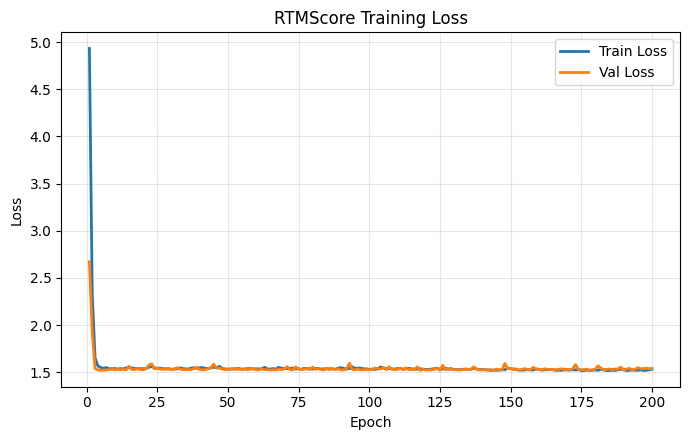

In [10]:
plot_loss_curves(train_loss_history, val_loss_history, title="RTMScore Training Loss")

## 总结

- 技术路线：混合密度网络 (MDN) 建模残基-原子距离分布。
- 教学骨架：`nn.Linear() + nn.ReLU()`。
- 主指标：`Pearson R` 和 `RMSE`（MDN 打分经线性回归映射后）。